<a href="https://colab.research.google.com/github/seeuni0320/AI-ML/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import numpy as np
import urllib.request
import tarfile
import pandas as pd

def  load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
  with tarfile.open(tarball_path) as housing_tarball:
    housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_296/2556904344.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


계층 샘플링용 income_cat 만들기

In [2]:
housing["income_cat"] = pd.cut(housing["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1,2,3,4,5])

train / test 분리

In [6]:
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

임시 칼럼 삭제

In [7]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

훈련 시트 복사

In [8]:
housing = strat_train_set.copy()

컬럼 이름 바꾸기

In [9]:
housing_renamed = housing.rename(columns={
    "latitude": "Latitude",
    "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value"
})

위도/경도만 사용해서 KMeans 학습

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt

geo = housing[["longitude", "latitude"]].values

cluster_simil_kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_simil_kmeans.fit(geo)

KMeans(n_clusters=10, n_init=10, random_state=42)

각 샘플과 각 군집 중심 사이의 유사도 계산
- gamma 값은 그림 모양에 영향을 줌 (0.1 ~ 1 사이 조절 가능)

In [12]:
similarities = rbf_kernel(geo, cluster_simil_kmeans.cluster_centers_, gamma=0.3)

각 데이터가 가장 비슷한 군집 중심과의 유사도

In [13]:
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

시각화 & 군집 중심 표시

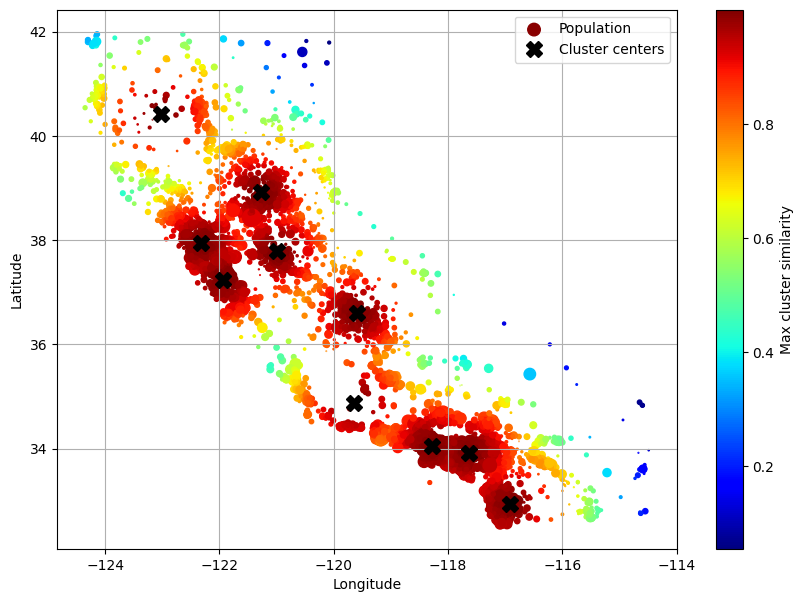

In [16]:
housing_renamed.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    grid=True,
    s=housing_renamed["Population"] / 100,
    label="Population",
    c="Max cluster similarity",
    cmap="jet",
    colorbar=True,
    sharex=False,
    figsize=(10, 7)
)
plt.plot(
    cluster_simil_kmeans.cluster_centers_[:, 0],
    cluster_simil_kmeans.cluster_centers_[:, 1],
    linestyle="",
    color="black",
    marker="X",
    markersize=12,
    label="Cluster centers"
)

plt.legend(loc="upper right")
plt.show()